# 논문 따라해보기

In [81]:
# 필요한 라이브러리 호출
import os
import sys
import math
import copy
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Layer, InputSpec, Dense, Dropout, Activation, Flatten, Input
)
from tensorflow.keras.optimizers import RMSprop, SGD, Adam
from tensorflow.keras import (
    initializers, regularizers, constraints, backend as K
)
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, History
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 재귀 제한 설정 (필요한 경우만 사용)
sys.setrecursionlimit(10000)


import matplotlib.pyplot as plt

In [82]:
train_sample = pd.read_csv("/Users/leehyunsong/Desktop/심화프로젝트/dataset/train.csv", header = 0, encoding = 'utf-8')
path = r'/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2'
all_files = sorted(glob.glob(path + "/*.csv"))  # experiment 순서대로 정렬하고 싶어서 sorted 추가
train_sample_np = np.array(train_sample.copy())

li_df = []  # experimet 하나씩 다 저장
for filename in all_files:
    df = pd.read_csv(filename, index_col = None, header = 0)
    li_df.append(df)

In [83]:
# 데이터 잘 불러왔나 확인 -> len 확인 결과 okay
print(all_files)
len(all_files)

['/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_01.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_02.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_03.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_04.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_05.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_06.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_07.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_08.csv', '/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2/experiment_09.csv', '/Users/leehyunsong/Desktop

25

In [84]:
df.head(0).T

""
X_ActualPosition
X_ActualVelocity
X_ActualAcceleration
X_SetPosition
X_SetVelocity
X_SetAcceleration
X_CurrentFeedback
X_DCBusVoltage
X_OutputCurrent
X_OutputVoltage


In [85]:
train_sample

,No,material,feedrate,clamp_pressure,tool_condition,machining_finalized,passed_visual_inspection
0,1,aluminum,6,4.0,unworn,yes,yes
1,2,aluminum,20,4.0,unworn,yes,yes
2,3,aluminum,6,3.0,unworn,yes,yes
3,4,aluminum,6,2.5,unworn,no,NaN
4,5,aluminum,20,3.0,unworn,no,NaN
5,6,aluminum,6,4.0,worn,yes,no
6,7,aluminum,20,4.0,worn,no,NaN
7,8,aluminum,20,4.0,worn,yes,no
8,9,aluminum,15,4.0,worn,yes,no
9,10,aluminum,12,4.0,worn,yes,no


In [86]:
train_sample_np

array([[1, 'aluminum', 6, 4.0, 'unworn', 'yes', 'yes'],
       [2, 'aluminum', 20, 4.0, 'unworn', 'yes', 'yes'],
       [3, 'aluminum', 6, 3.0, 'unworn', 'yes', 'yes'],
       [4, 'aluminum', 6, 2.5, 'unworn', 'no', nan],
       [5, 'aluminum', 20, 3.0, 'unworn', 'no', nan],
       [6, 'aluminum', 6, 4.0, 'worn', 'yes', 'no'],
       [7, 'aluminum', 20, 4.0, 'worn', 'no', nan],
       [8, 'aluminum', 20, 4.0, 'worn', 'yes', 'no'],
       [9, 'aluminum', 15, 4.0, 'worn', 'yes', 'no'],
       [10, 'aluminum', 12, 4.0, 'worn', 'yes', 'no'],
       [11, 'aluminum', 3, 4.0, 'unworn', 'yes', 'yes'],
       [12, 'aluminum', 3, 3.0, 'unworn', 'yes', 'yes'],
       [13, 'aluminum', 3, 4.0, 'worn', 'yes', 'yes'],
       [14, 'aluminum', 3, 3.0, 'worn', 'yes', 'yes'],
       [15, 'aluminum', 6, 3.0, 'worn', 'yes', 'yes'],
       [16, 'aluminum', 20, 3.0, 'worn', 'no', nan],
       [17, 'aluminum', 3, 2.5, 'unworn', 'yes', 'yes'],
       [18, 'aluminum', 3, 2.5, 'worn', 'yes', 'yes'],
       [19, 

In [87]:
# experiment 잘 담겼나 확인
len(li_df)

25

In [88]:
# 데이터 개수 확인
nb_pass = 0   # 정상
nb_pass_half = 0  # 공정 끝났는데 불량
nb_defective = 0  # 공정 중지

for i in range(len(train_sample_np)):
    if(train_sample_np[i,5] == 'no'):
        nb_defective += 1
    if((train_sample_np[i,5] == 'yes') and (train_sample_np[i,6] == 'yes')):
        nb_pass +=1
    if((train_sample_np[i,5] == 'yes') and (train_sample_np[i,6] == 'no')):
        nb_pass_half += 1

print(f'양품 : {nb_pass}개, 공정 마쳤지만 통과 못한 샘플 : {nb_pass_half}개, 공정 중지: {nb_defective}개 총 샘플 수 : {nb_pass + nb_pass_half + nb_defective}개')

양품 : 13개, 공정 마쳤지만 통과 못한 샘플 : 6개, 공정 중지: 6개 총 샘플 수 : 25개


In [89]:
# unworn = 마모 X, worn = 마모 0 컬럼에 대한 레이블 인코딩
def tool_condition(input):
    for i in range(len(input)):
        if input[i,4] == 'unworn':
            input[i,4] = 0
        else:
            input[i,4] = 1
    return input

In [90]:
# train_csv에 공정완료, 육안검사 여부 종합해서 공정 미완료(2), 공정 완료 + 불량(1), 공정 완료 + 정상(0)로 나누어 레이블 인코딩
def item_inspection(input):
    for i in range(len(input)):
        if(input[i,5] == 'no'):  # 공정 미완료 (공정 중지)
            input[i,6] = 2
        if((input[i,5] == 'yes') and (input[i,6] == 'no')): # 공정 완료 + 불량
            input[i,6] = 1
        if((input[i,5] == 'yes') and (input[i,6] == 'yes')): # 공정 완료 + 정상
            input[i,6] = 0
    return input

In [91]:
# 기계의 공정 상태 Prep, Layer1 Up/Down, Layer2 Up/Down, Layer3 Up/Down, Repositioning, End(end), Starting에 대해 각각 레이블 인코딩
def machining_process(input):
    for i in range(len(input)):
        if input[i, 47] == 'Prep':
            input[i, 47] = 0
        elif input[i, 47] == 'Layer 1 Up':
            input[i,47] = 1
        elif input[i, 47] == 'Layer 1 Down':
            input[i,47] = 2
        elif input[i, 47] == 'Layer 2 Up':
            input[i,47] = 3
        elif input[i, 47] == 'Layer 2 Down':
            input[i, 47] = 4
        elif input[i, 47] == 'Layer 3 Up':
            input[i, 47] = 5
        elif input[i, 47] == 'Layer 3 Down':
            input[i, 47] = 6
        elif input[i, 47] == 'Repositioning':
            input[i, 47] = 7
        elif input[i, 47] == 'End' or 'end':
            input[i, 47] = 8
        elif input[i, 47] == 'Starting':
            input[i, 47] = 9
    return input

In [92]:
# 함수 전처리 적용
train_sample_info = np.array(train_sample_np.copy())
train_sample_info = tool_condition(train_sample_info)
train_sample_info = item_inspection(train_sample_info)
print(train_sample_info)

[[1 'aluminum' 6 4.0 0 'yes' 0]
 [2 'aluminum' 20 4.0 0 'yes' 0]
 [3 'aluminum' 6 3.0 0 'yes' 0]
 [4 'aluminum' 6 2.5 0 'no' 2]
 [5 'aluminum' 20 3.0 0 'no' 2]
 [6 'aluminum' 6 4.0 1 'yes' 1]
 [7 'aluminum' 20 4.0 1 'no' 2]
 [8 'aluminum' 20 4.0 1 'yes' 1]
 [9 'aluminum' 15 4.0 1 'yes' 1]
 [10 'aluminum' 12 4.0 1 'yes' 1]
 [11 'aluminum' 3 4.0 0 'yes' 0]
 [12 'aluminum' 3 3.0 0 'yes' 0]
 [13 'aluminum' 3 4.0 1 'yes' 0]
 [14 'aluminum' 3 3.0 1 'yes' 0]
 [15 'aluminum' 6 3.0 1 'yes' 0]
 [16 'aluminum' 20 3.0 1 'no' 2]
 [17 'aluminum' 3 2.5 0 'yes' 0]
 [18 'aluminum' 3 2.5 1 'yes' 0]
 [19 'aluminum' 15 4.0 1 'yes' 1]
 [20 'aluminum' 12 4.0 0 'no' 2]
 [21 'aluminum' 3 4.0 0 'yes' 1]
 [22 'aluminum' 20 3.0 1 'yes' 0]
 [23 'aluminum' 3 4.0 1 'no' 2]
 [24 'aluminum' 3 3.0 0 'yes' 0]
 [25 'aluminum' 6 2.5 1 'yes' 0]]


In [93]:
# 라벨 인코딩 해서 yes/no 필요없으니 삭제 

train_sample_info = np.delete(train_sample_info, 5, 1)

In [94]:
# 작업 번호, 작업 소재, Tool 이동 속도, 소재 Clamp 압력, Tool condition(마모 O:1, 마모 x : 0), 작업중단품(2)/불량품(1)/양품(0)
print(train_sample_info)

[[1 'aluminum' 6 4.0 0 0]
 [2 'aluminum' 20 4.0 0 0]
 [3 'aluminum' 6 3.0 0 0]
 [4 'aluminum' 6 2.5 0 2]
 [5 'aluminum' 20 3.0 0 2]
 [6 'aluminum' 6 4.0 1 1]
 [7 'aluminum' 20 4.0 1 2]
 [8 'aluminum' 20 4.0 1 1]
 [9 'aluminum' 15 4.0 1 1]
 [10 'aluminum' 12 4.0 1 1]
 [11 'aluminum' 3 4.0 0 0]
 [12 'aluminum' 3 3.0 0 0]
 [13 'aluminum' 3 4.0 1 0]
 [14 'aluminum' 3 3.0 1 0]
 [15 'aluminum' 6 3.0 1 0]
 [16 'aluminum' 20 3.0 1 2]
 [17 'aluminum' 3 2.5 0 0]
 [18 'aluminum' 3 2.5 1 0]
 [19 'aluminum' 15 4.0 1 1]
 [20 'aluminum' 12 4.0 0 2]
 [21 'aluminum' 3 4.0 0 1]
 [22 'aluminum' 20 3.0 1 0]
 [23 'aluminum' 3 4.0 1 2]
 [24 'aluminum' 3 3.0 0 0]
 [25 'aluminum' 6 2.5 1 0]]


In [95]:
path = r'/Users/leehyunsong/Desktop/심화프로젝트/dataset/CNC 비식별화 원본데이터_1209/CNC Virtual Data set _v2'
all_files = sorted(glob.glob(path + "/*.csv"))  # experiment 순서대로 정렬하고 싶어서 sorted 추가

k = 0
li_pass = []
li_pass_half = []
li_fail = []
for filename in all_files:
    df = pd.read_csv(filename, index_col = None, header = 0)

    if train_sample_info[k,5] == 0:  # 양품
        li_pass.append(df)
    elif train_sample_info[k,5] == 1: # 불량품
        li_pass_half.append(df)
    else:  # 작업 중단품
        li_fail.append(df)
    k += 1

frame01 = pd.concat(li_pass, axis = 0, ignore_index = True)
frame02 = pd.concat(li_pass_half, axis = 0, ignore_index = True)
frame03 = pd.concat(li_fail, axis = 0, ignore_index = True)
data_pass = np.array(frame01.copy())
data_pass_half = np.array(frame02.copy())
data_fail = np.array(frame03.copy())

print(f'공정완료 및 육안검사 합격한 전체 데이터 수 : {len(data_pass)}')
print(f'공정완료 및 육안검사 불합격한 전체 데이터 수 : {len(data_pass_half)}')
print(f'공정중지된 전체 데이터 수 : {len(data_fail)}')
print(f'전체 데이터: {len(data_pass) + len(data_pass_half) + len(data_fail)}')

공정완료 및 육안검사 합격한 전체 데이터 수 : 22645
공정완료 및 육안검사 불합격한 전체 데이터 수 : 6175
공정중지된 전체 데이터 수 : 3228
전체 데이터: 32048


In [96]:
# experiment 데이터 다 들어갔나 확인 -> 굿굿~
sum = 0
for i in range(len(li_df)):
    sum += len(li_df[i])

print(sum)


32048


In [97]:
data_pass.shape, data_pass_half.shape , data_fail.shape

((22645, 48), (6175, 48), (3228, 48))

In [98]:
# 기계의 공정 상태 레이블 인코딩 적용
data_pass = machining_process(data_pass)
data_pass_half = machining_process(data_pass_half)
data_fail = machining_process(data_fail)

In [99]:
data_pass

array([[202.0, 4.0, 4.0, ..., 0, 50, 8],
       [202.0, -6.8, -346.0, ..., 4, 50, 0],
       [200.0, -13.8, -2.25, ..., 7, 50, 0],
       ...,
       [178.5, 3.5475, 17.5, ..., 0, 20, 8],
       [178.5, 3.4475, 11.25, ..., 0, 20, 8],
       [178.0, 3.5625, 1.85, ..., 0, 20, 8]], dtype=object)

In [100]:
data01 = data_pass[0:3228 + 6175, :] # 양품 뽑기 (공평하게 뽑기 위해 3228+6175개 뽑음)
data02 = data_pass_half[0:6175, :] # 불량품 다 뽑기
data03 = data_fail[0:3228, :]  # 중단품 다 뽑기
data = np.concatenate((data01, data02), axis = 0) 
data = np.concatenate((data, data03), axis = 0)
data_all = data_pass[3228 + 6175:22645, :]  # 양품 중에 data에 안 속한 애들 -> 평가 데이터 셋으로 활용 예정

print((data))
print(data.shape)
print(data_all.shape)

[[202.0 4.0 4.0 ... 0 50 8]
 [202.0 -6.8 -346.0 ... 4 50 0]
 [200.0 -13.8 -2.25 ... 7 50 0]
 ...
 [155.0 9.875 -64.6 ... 0 50 8]
 [155.5 9.95 -52.125 ... 0 50 8]
 [156.0 10.1 76.125 ... 0 50 8]]
(18806, 48)
(13242, 48)


In [101]:
# 학습 데이터/ 테스트 테이터 분리 and MinMaxScaler 이용해서 최소 최대 0~1로 조정
sc  = MinMaxScaler()
X_train = sc.fit_transform(data)
X_train = np.array(X_train)
X_test = sc.fit_transform(data_all)
X_test = np.array(X_test)

In [102]:
# Y_test는 다 양품으로 구성되어 있으니 0으로 채운거 그대로 쓰면 댐
Y_train = np.zeros((len(X_train), 1), dtype = 'int')
Y_test = np.zeros((len(X_test),1), dtype = 'int')
l = int(Y_train.shape[0]/2)
Y_train[0:l, :] = 0  # 절반이 양품 
Y_train[l:l*2,:] = 1 # 절반이 불량품 + 중단품 
print(Y_train)
print(Y_test)


[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


In [103]:
nb_classes = 2
batch_size = 1024
epochs = 300
lr = 1e-4

In [104]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
Y_train = to_categorical(Y_train, nb_classes)
Y_test = to_categorical(Y_test, nb_classes)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((18806, 48), (13242, 48), (18806, 2), (13242, 2))

In [105]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim = 48))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(nb_classes, activation = 'sigmoid'))
model_checkpoint = ModelCheckpoint('weight_CNC_binary.keras', monitor = 'val_acc', save_best_only = True)
opt = Adam(lr)
model.summary()
model.compile(optimizer = opt, loss = 'binary_crossentropy', metrics =['accuracy'])
history = History()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,018 (2.28 MB)

 Trainable params: 598,018 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [106]:
model.fit(X_train, Y_train, verbose = 2, batch_size = batch_size, epochs = 20, validation_split= 0.1, shuffle= True, callbacks = [history])
model.save_weights('weight_CNC_binary.weights.h5')

Epoch 1/20
17/17 - 2s - 117ms/step - accuracy: 0.5489 - loss: 0.6895 - val_accuracy: 0.0000e+00 - val_loss: 0.7834
Epoch 2/20
17/17 - 0s - 27ms/step - accuracy: 0.5576 - loss: 0.6806 - val_accuracy: 0.0064 - val_loss: 0.7720
Epoch 3/20
17/17 - 0s - 24ms/step - accuracy: 0.5732 - loss: 0.6690 - val_accuracy: 0.4801 - val_loss: 0.7513
Epoch 4/20
17/17 - 0s - 24ms/step - accuracy: 0.6133 - loss: 0.6525 - val_accuracy: 0.6709 - val_loss: 0.6912
Epoch 5/20
17/17 - 0s - 24ms/step - accuracy: 0.6516 - loss: 0.6345 - val_accuracy: 0.7554 - val_loss: 0.6133
Epoch 6/20
17/17 - 0s - 27ms/step - accuracy: 0.6733 - loss: 0.6088 - val_accuracy: 0.8926 - val_loss: 0.5531
Epoch 7/20
17/17 - 1s - 77ms/step - accuracy: 0.6955 - loss: 0.5786 - val_accuracy: 0.9633 - val_loss: 0.4879
Epoch 8/20
17/17 - 2s - 103ms/step - accuracy: 0.7183 - loss: 0.5458 - val_accuracy: 0.9708 - val_loss: 0.4646
Epoch 9/20
17/17 - 1s - 79ms/step - accuracy: 0.7310 - loss: 0.5239 - val_accuracy: 0.9910 - val_loss: 0.4240
Epoc

In [107]:
loss_and_metrics = model.evaluate(X_train, Y_train, batch_size = 32)
loss_and_metrics2 = model.evaluate(X_test, Y_test, batch_size = 32)
loss_and_metrics, loss_and_metrics2

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8681 - loss: 0.3297
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9548 - loss: 0.1394


([0.2731119990348816, 0.8962565064430237],
 [0.31639689207077026, 0.8877058029174805])

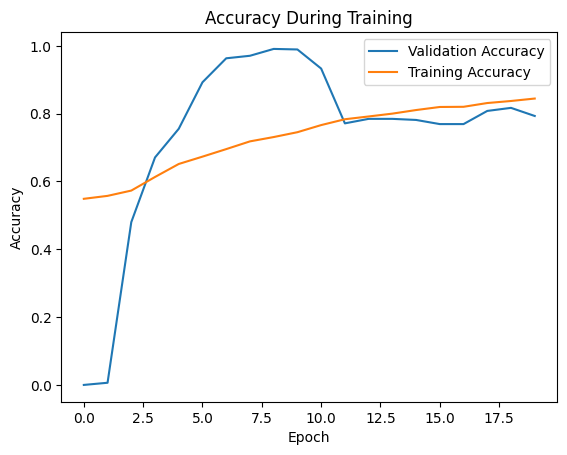

In [108]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.title('Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Validation Accuracy', 'Training Accuracy'])

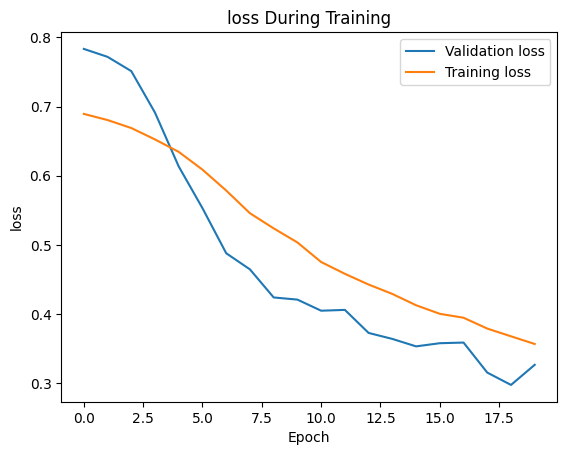

In [109]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])
plt.title('loss During Training')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend(['Validation loss', 'Training loss'])

-> 11개가 최적일듯함 약 12번째 에포크에서 과대적합 발생함

# 논문 따라 해보기 끝

# 머신러닝 이용하여 Feature Importance 보기

In [110]:
# catboost 사용
from catboost import CatBoostRegressor

X_train = pd.DataFrame(X_train)
cat_clf = CatBoostRegressor(loss_function='MultiRMSE', verbose=0)
cat_clf.fit(X_train , Y_train)
feature_importance = cat_clf.feature_importances_



real_columns_name = [
    'X_ActualPosition', 'X_ActualVelocity', 'X_ActualAcceleration',
    'X_SetPosition', 'X_SetVelocity', 'X_SetAcceleration',
    'X_CurrentFeedback', 'X_DCBusVoltage', 'X_OutputCurrent',
    'X_OutputVoltage', 'X_OutputPower', 'Y_ActualPosition',
    'Y_ActualVelocity', 'Y_ActualAcceleration', 'Y_SetPosition',
    'Y_SetVelocity', 'Y_SetAcceleration', 'Y_CurrentFeedback',
    'Y_DCBusVoltage', 'Y_OutputCurrent', 'Y_OutputVoltage',
    'Y_OutputPower', 'Z_ActualPosition', 'Z_ActualVelocity',
    'Z_ActualAcceleration', 'Z_SetPosition', 'Z_SetVelocity',
    'Z_SetAcceleration', 'Z_CurrentFeedback', 'Z_DCBusVoltage',
    'Z_OutputCurrent', 'Z_OutputVoltage', 'S_ActualPosition',
    'S_ActualVelocity', 'S_ActualAcceleration', 'S_SetPosition',
    'S_SetVelocity', 'S_SetAcceleration', 'S_CurrentFeedback',
    'S_DCBusVoltage', 'S_OutputCurrent', 'S_OutputVoltage',
    'S_OutputPower', 'S_SystemInertia', 'M_CURRENT_PROGRAM_NUMBER',
    'M_sequence_number', 'M_CURRENT_FEEDRATE', 'Machining_Process'
]


feature_names = [f'{real_columns_name[i]}' for i in range(X_train.shape[1])]


feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)



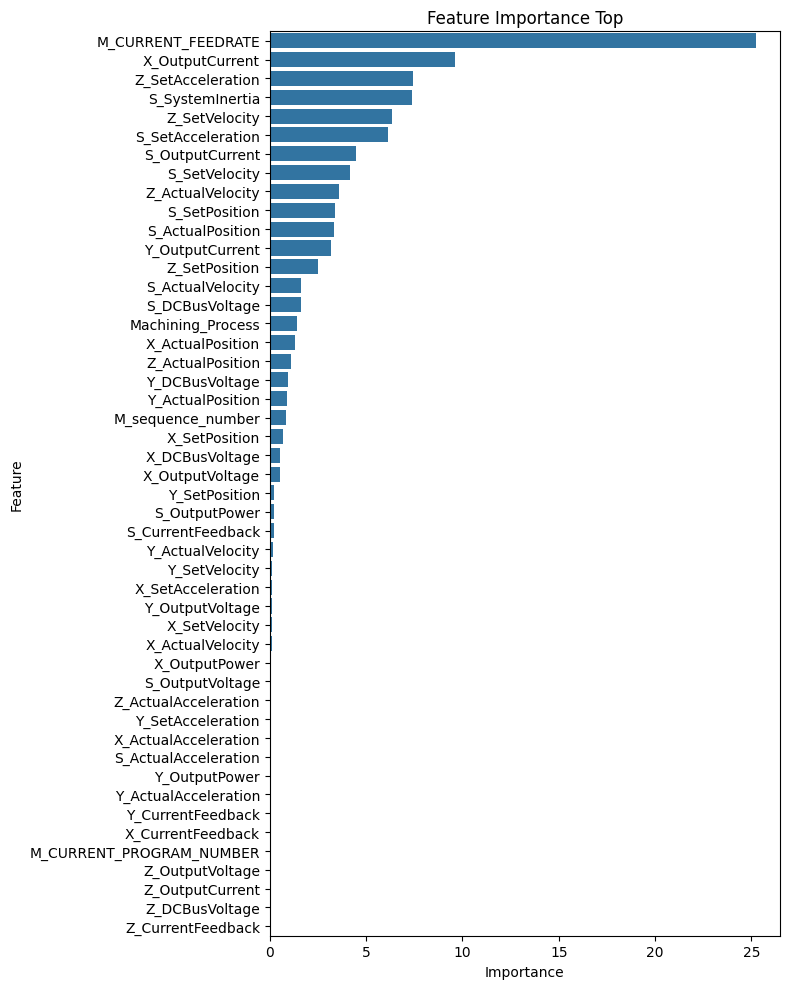

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.title('Feature Importance Top')
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')

plt.tight_layout()
plt.show()

In [112]:
from sklearn.ensemble import RandomForestRegressor 
import seaborn as sns

rf_clf = RandomForestRegressor()
rf_clf.fit(X_train , Y_train)
feature_importance = rf_clf.feature_importances_

real_columns_name = [
    'X_ActualPosition', 'X_ActualVelocity', 'X_ActualAcceleration',
    'X_SetPosition', 'X_SetVelocity', 'X_SetAcceleration',
    'X_CurrentFeedback', 'X_DCBusVoltage', 'X_OutputCurrent',
    'X_OutputVoltage', 'X_OutputPower', 'Y_ActualPosition',
    'Y_ActualVelocity', 'Y_ActualAcceleration', 'Y_SetPosition',
    'Y_SetVelocity', 'Y_SetAcceleration', 'Y_CurrentFeedback',
    'Y_DCBusVoltage', 'Y_OutputCurrent', 'Y_OutputVoltage',
    'Y_OutputPower', 'Z_ActualPosition', 'Z_ActualVelocity',
    'Z_ActualAcceleration', 'Z_SetPosition', 'Z_SetVelocity',
    'Z_SetAcceleration', 'Z_CurrentFeedback', 'Z_DCBusVoltage',
    'Z_OutputCurrent', 'Z_OutputVoltage', 'S_ActualPosition',
    'S_ActualVelocity', 'S_ActualAcceleration', 'S_SetPosition',
    'S_SetVelocity', 'S_SetAcceleration', 'S_CurrentFeedback',
    'S_DCBusVoltage', 'S_OutputCurrent', 'S_OutputVoltage',
    'S_OutputPower', 'S_SystemInertia', 'M_CURRENT_PROGRAM_NUMBER',
    'M_sequence_number', 'M_CURRENT_FEEDRATE', 'Machining_Process'
]


feature_names = [f'{real_columns_name[i]}' for i in range(X_train.shape[1])]


feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)
    

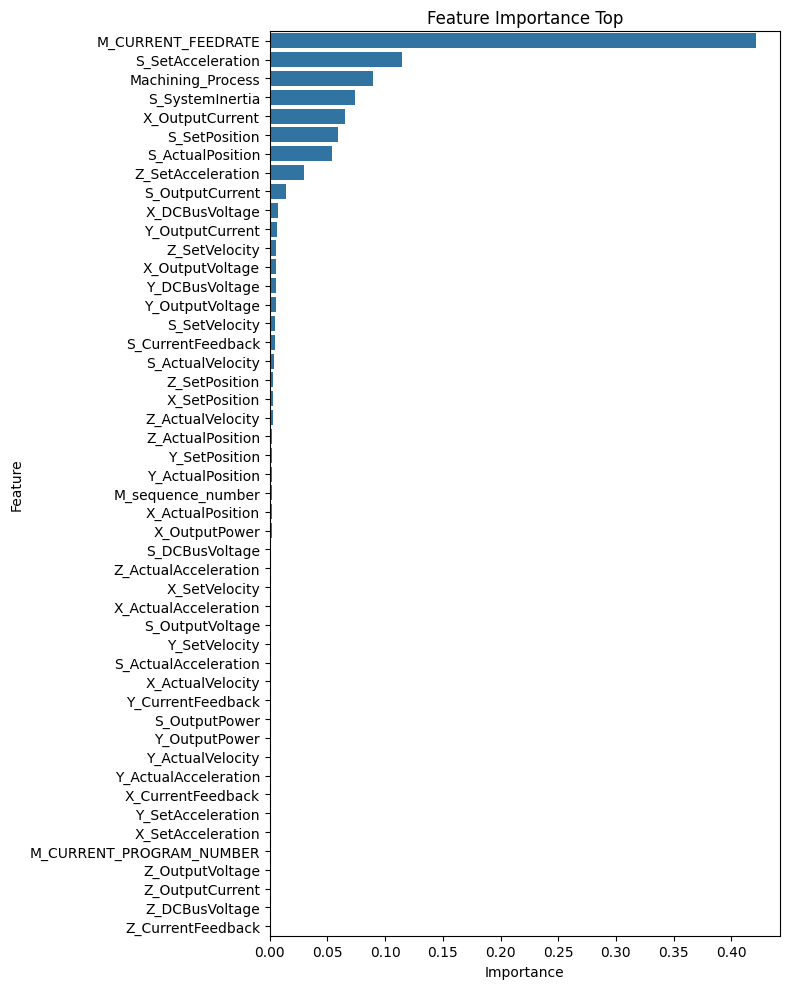

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.title('Feature Importance Top')
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')

plt.tight_layout()
plt.show()

# 동진님 추가 데이터 + Feature Importance

In [56]:
df_dong = pd.read_csv("/Users/leehyunsong/Desktop/심화프로젝트/dataset/concat.csv", header = 0, encoding = 'utf-8')

In [57]:
df_dong

,X_ActualPosition,X_ActualVelocity,X_ActualAcceleration,X_SetPosition,X_SetVelocity,X_SetAcceleration,X_CurrentFeedback,X_DCBusVoltage,X_OutputCurrent,X_OutputVoltage,...,S_SystemInertia,M_CURRENT_PROGRAM_NUMBER,M_sequence_number,M_CURRENT_FEEDRATE,Machining_Process,X_different,Y_different,Z_different,S_different,normal
0,202.0,4.0000,4.00,202.0,4.0,4.000000,0.180,0.0207,329,2.77,...,16.0,1,0,50,0,0.0,0.0,0.0,0.0,1
1,202.0,-6.8000,-346.00,202.0,-9.6,-354.000000,-10.900,0.1860,328,23.30,...,16.0,1,4,50,1,0.0,-1.0,-1.0,0.0,1
2,200.0,-13.8000,-2.25,200.0,-13.9,3.999905,-8.590,0.1400,328,30.60,...,16.0,1,7,50,1,0.0,0.0,0.0,0.0,1
3,198.0,-14.0000,4.00,198.0,-13.9,3.999905,-6.110,0.1300,327,30.30,...,16.0,1,7,50,1,0.0,0.0,0.0,0.0,1
4,197.0,-13.9000,-14.80,196.0,-13.9,4.000095,-5.700,0.1140,328,30.50,...,16.0,1,7,50,1,-1.0,0.0,-1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32043,179.0,3.5625,8.15,179.0,3.5,5.000000,-0.941,0.0215,328,1.79,...,17.0,1,0,20,9,0.0,0.0,0.0,0.5,1
32044,178.5,3.5350,30.00,178.5,3.5,5.000000,-0.780,0.0202,328,1.07,...,17.0,1,0,20,9,0.0,0.0,0.0,0.5,1
32045,178.5,3.5475,17.50,178.5,3.5,5.000000,0.501,0.0190,328,0.99,...,17.0,1,0,20,9,0.0,0.0,0.0,0.0,1
32046,178.5,3.4475,11.25,178.5,3.5,5.000000,-0.298,0.0193,328,1.37,...,17.0,1,0,20,9,0.0,0.0,0.0,0.5,1


In [ ]:
df_dong_pass = df_dong[df_dong['normal'] == 1] 

In [63]:
df_dong_fail = df_dong[df_dong['normal'] == 0]

In [66]:
data01 = np.array(df_dong_pass)[0:3228 + 6175, :] # 양품 뽑기 (공평하게 뽑기 위해 3228+6175개 뽑음)
data02 = np.array(df_dong_fail)[0:9403, :] # 불량품 다 뽑기
data = np.concatenate((data01, data02), axis = 0) 
data_all = data_pass[3228 + 6175:22645, :]  # 양품 중에 data에 안 속한 애들 -> 평가 데이터 셋으로 활용 예정

print((data))
print(data.shape)
print(data_all.shape)

[[ 2.0200e+02  4.0000e+00  4.0000e+00 ...  0.0000e+00  0.0000e+00
   1.0000e+00]
 [ 2.0200e+02 -6.8000e+00 -3.4600e+02 ... -1.0000e+00  0.0000e+00
   1.0000e+00]
 [ 2.0000e+02 -1.3800e+01 -2.2500e+00 ...  0.0000e+00  0.0000e+00
   1.0000e+00]
 ...
 [ 1.5500e+02  9.8750e+00 -6.4600e+01 ...  2.5000e-01  0.0000e+00
   0.0000e+00]
 [ 1.5550e+02  9.9500e+00 -5.2125e+01 ...  2.0000e-01  0.0000e+00
   0.0000e+00]
 [ 1.5600e+02  1.0100e+01  7.6125e+01 ...  2.0000e-01  0.0000e+00
   0.0000e+00]]
(18806, 53)
(13242, 48)


In [67]:
# 학습 데이터/ 테스트 테이터 분리 and MinMaxScaler 이용해서 최소 최대 0~1로 조정
sc  = MinMaxScaler()
X_train = sc.fit_transform(data)
X_train = np.array(X_train)
X_test = sc.fit_transform(data_all)
X_test = np.array(X_test)

In [69]:
# Y_test는 다 양품으로 구성되어 있으니 0으로 채운거 그대로 쓰면 댐
Y_train = np.zeros((len(X_train), 1), dtype = 'int')
Y_test = np.zeros((len(X_test),1), dtype = 'int')
l = int(Y_train.shape[0]/2)
Y_train[0:l, :] = 1  # 절반이 양품 
Y_train[l:l*2,:] = 0 # 절반이 불량품 + 중단품 
print(Y_train)
print(Y_test)


[[1]
 [1]
 [1]
 ...
 [0]
 [0]
 [0]]
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


In [75]:
X_train = np.delete(X_train, 52, 1)

In [76]:
# catboost 사용
from catboost import CatBoostRegressor

X_train = pd.DataFrame(X_train)
cat_clf = CatBoostRegressor(loss_function='MultiRMSE', verbose=0)
cat_clf.fit(X_train , Y_train)
feature_importance = cat_clf.feature_importances_



real_columns_name = [
    'X_ActualPosition', 'X_ActualVelocity', 'X_ActualAcceleration',
    'X_SetPosition', 'X_SetVelocity', 'X_SetAcceleration',
    'X_CurrentFeedback', 'X_DCBusVoltage', 'X_OutputCurrent',
    'X_OutputVoltage', 'X_OutputPower', 'Y_ActualPosition',
    'Y_ActualVelocity', 'Y_ActualAcceleration', 'Y_SetPosition',
    'Y_SetVelocity', 'Y_SetAcceleration', 'Y_CurrentFeedback',
    'Y_DCBusVoltage', 'Y_OutputCurrent', 'Y_OutputVoltage',
    'Y_OutputPower', 'Z_ActualPosition', 'Z_ActualVelocity',
    'Z_ActualAcceleration', 'Z_SetPosition', 'Z_SetVelocity',
    'Z_SetAcceleration', 'Z_CurrentFeedback', 'Z_DCBusVoltage',
    'Z_OutputCurrent', 'Z_OutputVoltage', 'S_ActualPosition',
    'S_ActualVelocity', 'S_ActualAcceleration', 'S_SetPosition',
    'S_SetVelocity', 'S_SetAcceleration', 'S_CurrentFeedback',
    'S_DCBusVoltage', 'S_OutputCurrent', 'S_OutputVoltage',
    'S_OutputPower', 'S_SystemInertia', 'M_CURRENT_PROGRAM_NUMBER',
    'M_sequence_number', 'M_CURRENT_FEEDRATE', 'Machining_Process', 'X_different', 'Y_different', 'Z_different', 'S_different'
]


feature_names = [f'{real_columns_name[i]}' for i in range(X_train.shape[1])]


feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)



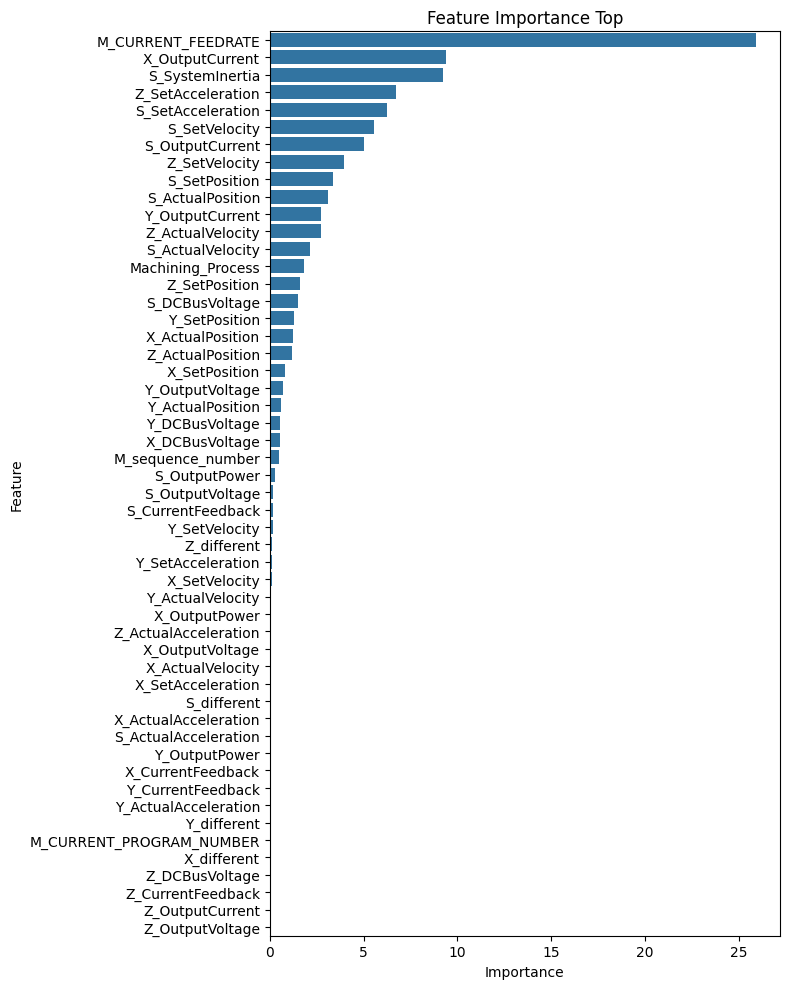

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.title('Feature Importance Top')
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')

plt.tight_layout()
plt.show()

In [79]:
from sklearn.ensemble import RandomForestRegressor 
import seaborn as sns

rf_clf = RandomForestRegressor()
rf_clf.fit(X_train , Y_train)
feature_importance = rf_clf.feature_importances_

real_columns_name = [
    'X_ActualPosition', 'X_ActualVelocity', 'X_ActualAcceleration',
    'X_SetPosition', 'X_SetVelocity', 'X_SetAcceleration',
    'X_CurrentFeedback', 'X_DCBusVoltage', 'X_OutputCurrent',
    'X_OutputVoltage', 'X_OutputPower', 'Y_ActualPosition',
    'Y_ActualVelocity', 'Y_ActualAcceleration', 'Y_SetPosition',
    'Y_SetVelocity', 'Y_SetAcceleration', 'Y_CurrentFeedback',
    'Y_DCBusVoltage', 'Y_OutputCurrent', 'Y_OutputVoltage',
    'Y_OutputPower', 'Z_ActualPosition', 'Z_ActualVelocity',
    'Z_ActualAcceleration', 'Z_SetPosition', 'Z_SetVelocity',
    'Z_SetAcceleration', 'Z_CurrentFeedback', 'Z_DCBusVoltage',
    'Z_OutputCurrent', 'Z_OutputVoltage', 'S_ActualPosition',
    'S_ActualVelocity', 'S_ActualAcceleration', 'S_SetPosition',
    'S_SetVelocity', 'S_SetAcceleration', 'S_CurrentFeedback',
    'S_DCBusVoltage', 'S_OutputCurrent', 'S_OutputVoltage',
    'S_OutputPower', 'S_SystemInertia', 'M_CURRENT_PROGRAM_NUMBER',
    'M_sequence_number', 'M_CURRENT_FEEDRATE', 'Machining_Process', 'X_different', 'Y_different', 'Z_different', 'S_different'
]


feature_names = [f'{real_columns_name[i]}' for i in range(X_train.shape[1])]


feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)
    

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


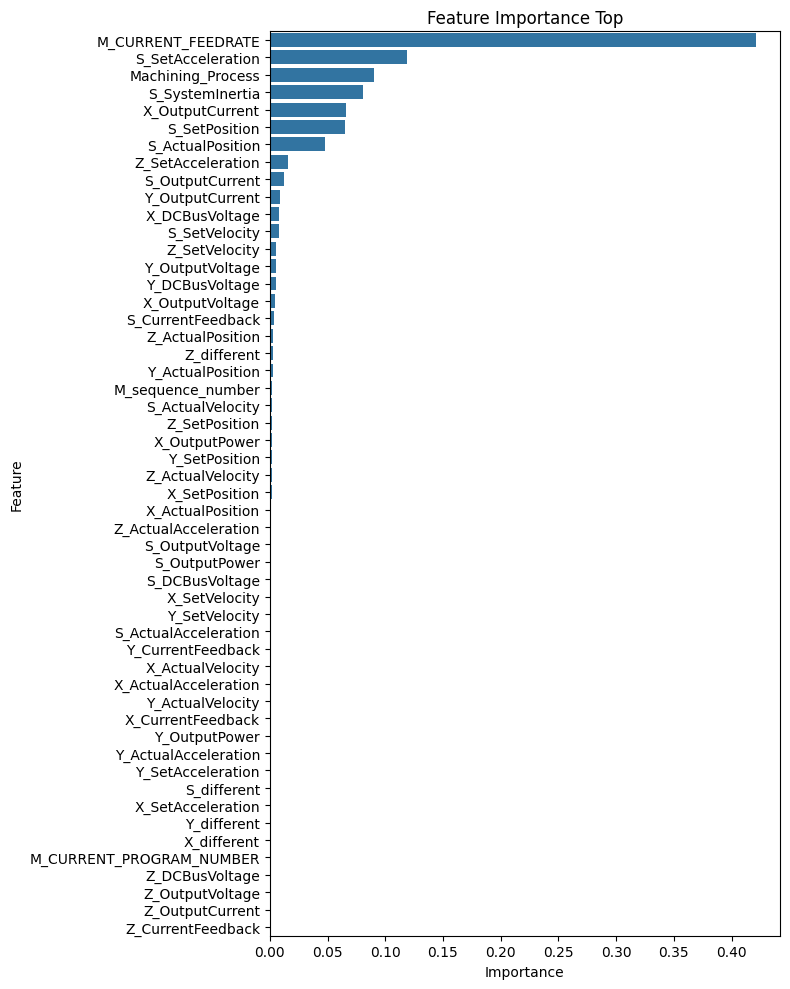

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))
plt.title('Feature Importance Top')
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')

plt.tight_layout()
plt.show()